# Indonesia Rice Early Warning

Proyeksi pasokan beras per provinsi untuk usaha makanan yang menyajikan nasi
dalam volume tetap (rumah makan, katering, kantin).

Model memprediksi **produksi padi bulanan per provinsi**, lalu membandingkannya
dengan rata-rata bulan yang sama pada tahun-tahun sebelumnya untuk menentukan
status pasokan: **ketat / normal / longgar**. Harga dipakai sebagai alat
validasi, bukan target model.

# Library

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 4)

# Data Understanding

Dataset: `data/processed/dataset_gabungan.csv`

Gabungan tiga sumber pada resolusi provinsi-bulan:

| Sumber | Isi | Cakupan |
|---|---|---|
| BPS (KSA) | luas panen, produksi, fase tanam | 2018-01 s.d. 2026-10 |
| NASA POWER (MERRA-2) | curah hujan, suhu | 2016-01 s.d. 2026-09 |
| NOAA CPC / NOAA PSL | indeks ONI | 2016-01 s.d. 2026-08 |

Cakupan: 2016-01 s.d. 2026-10, bulanan, 38 provinsi. 4.940 baris, 29 kolom.

Rentang sengaja dimulai 2016, dua tahun lebih awal daripada data produksi, supaya
tersedia bahan lag iklim untuk baris produksi paling awal (Januari 2018). Baris
2016–2017 hanya berisi kolom iklim; kolom produksi kosong.

Ketiga sumber punya keterlambatan terbit yang berbeda, dan ini menentukan fitur
mana yang benar-benar tersedia saat prediksi dibuat:

| Data | Terbaru | Ketinggalan |
|---|---|---|
| Produksi BPS (realisasi) | April 2026 | ~5 bulan |
| Curah hujan dan suhu | September 2026 | ~0 bulan |
| ONI | Agustus 2026 | ~1 bulan |

In [3]:
gab = pd.read_csv(ROOT / "data/processed/dataset_gabungan.csv", parse_dates=["tanggal"])
gab.head(3)

,tanggal,tahun,bulan,provinsi,wilayah_34,sumber,status_luas_panen,status_produksi,luas_panen_ha,produksi_padi_ton_gkg,produksi_beras_ton,standing_crop_ha,vegetatif_awal_ha,vegetatif_akhir_ha,generatif_ha,persiapan_lahan_ha,potensi_gagal_panen_ha,lahan_bera_ha,tanaman_selain_padi_ha,curah_hujan_mm,suhu_rata_c,suhu_maks_c,suhu_min_c,n_kab_kota,hari_data,oni,dmi,fase_enso,fase_iod
0,2016-01-01,2016,1,Aceh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,241.26,24.72,27.56,22.57,23.0,31.0,2.59,0.265,El Nino,Netral
1,2016-02-01,2016,2,Aceh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.07,24.50,27.44,22.19,23.0,29.0,2.50,-0.110,El Nino,Netral
2,2016-03-01,2016,3,Aceh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118.55,25.37,28.38,23.17,23.0,31.0,2.21,-0.008,El Nino,Netral


In [4]:
gab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4940 entries, 0 to 4939
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   tanggal                 4940 non-null   datetime64[ns]
 1   tahun                   4940 non-null   int64         
 2   bulan                   4940 non-null   int64         
 3   provinsi                4940 non-null   object        
 4   wilayah_34              3788 non-null   object        
 5   sumber                  3788 non-null   object        
 6   status_luas_panen       3788 non-null   object        
 7   status_produksi         3788 non-null   object        
 8   luas_panen_ha           3788 non-null   float64       
 9   produksi_padi_ton_gkg   3788 non-null   float64       
 10  produksi_beras_ton      3788 non-null   float64       
 11  standing_crop_ha        3408 non-null   float64       
 12  vegetatif_awal_ha       3408 non-null   float64 

## Data Description

### Kolom identitas

| Kolom | Penjelasan |
|---|---|
| `tanggal` | Awal bulan periode data, format `YYYY-MM-01`. Nilainya mewakili **satu bulan penuh**, bukan satu hari |
| `tahun` | Tahun (2016–2026) |
| `bulan` | Bulan, 1 = Januari sampai 12 = Desember |
| `provinsi` | Nama provinsi. 34 provinsi pada 2018–2022, 38 provinsi mulai 2023 setelah pemekaran Papua |
| `wilayah_34` | Provinsi induk sebelum pemekaran. Papua Selatan, Papua Tengah, dan Papua Pegunungan dipetakan ke **Papua**; Papua Barat Daya ke **Papua Barat**. Dipakai kalau ingin membandingkan wilayah secara konsisten sepanjang 2018–2026 |

### Kolom asal dan kualitas data

| Kolom | Penjelasan |
|---|---|
| `sumber` | Asal data. `publikasi` = PDF publikasi tahunan BPS (2018–2025). `webapi` = WebAPI BPS (2026) |
| `status_luas_panen` | Kualitas angka luas panen. `tetap` = angka final. `sementara` = hasil survei, masih bisa direvisi. `potensi` = **perkiraan BPS** dari tanaman yang sedang tumbuh, belum dipanen |
| `status_produksi` | Sama seperti di atas, untuk produksi. Pada 2026: Januari–April `sementara`, Mei–Oktober `potensi` |

Baris berstatus `potensi` adalah **forecast versi BPS**, bukan hasil pengukuran; dipakai sebagai pembanding.

### Kolom hasil panen

| Kolom | Satuan | Penjelasan |
|---|---|---|
| `luas_panen_ha` | hektare | Luas sawah yang dipanen pada bulan tersebut |
| `produksi_padi_ton_gkg` | ton GKG | Produksi padi dalam bentuk **Gabah Kering Giling**. Dihitung BPS sebagai luas panen × produktivitas (hasil survei ubinan). **Target utama model** |
| `produksi_beras_ton` | ton beras | Produksi beras siap konsumsi. Setara 57,6% dari GKG, yaitu rendemen giling 64,02% dikurangi susut, benih, pakan ternak, dan penggunaan non-pangan. Untuk 2026 kolom ini **kami hitung sendiri** dengan faktor 0,5762 karena tidak tersedia di API |

### Kolom fase tanam (hasil pengamatan KSA)

Setiap bulan BPS mengamati ribuan titik sampel dan mencatat kondisi lahannya. Kolom berikut adalah luas lahan pada tiap kondisi. **Hanya tersedia 2018–2025** (dari publikasi PDF); untuk 2026 masih kosong (`NaN`) sampai publikasi edisi 2026 terbit.

| Kolom | Satuan | Penjelasan |
|---|---|---|
| `vegetatif_awal_ha` | hektare | Padi baru ditanam sampai anakan awal. Umumnya dipanen sekitar **3 bulan** kemudian |
| `vegetatif_akhir_ha` | hektare | Padi menjelang berbunga. Umumnya dipanen sekitar **2 bulan** kemudian |
| `generatif_ha` | hektare | Padi sudah berbunga sampai bulir menua. Umumnya dipanen **1 bulan** kemudian |
| `standing_crop_ha` | hektare | Total tanaman padi yang sedang berdiri. **Merupakan penjumlahan tiga kolom di atas** (terverifikasi, selisih ≤ 0,5 ha). Jangan dipakai bersamaan dengan ketiganya sebagai fitur model karena kolinearitas sempurna |
| `persiapan_lahan_ha` | hektare | Lahan sedang diolah atau digenangi, siap ditanami |
| `lahan_bera_ha` | hektare | Lahan sawah dibiarkan kosong (diberakan). Catatan: Januari 2018 bernilai 0 di semua provinsi, kemungkinan **belum didata**, bukan benar-benar nol |
| `tanaman_selain_padi_ha` | hektare | Lahan sawah yang ditanami komoditas lain, misalnya jagung atau sayuran |
| `potensi_gagal_panen_ha` | hektare | Luas tanaman yang berpotensi gagal panen (puso) akibat banjir, kekeringan, atau serangan hama. Di publikasi 2019–2020 istilahnya "Luas Puso"; angkanya identik, jadi digabung jadi satu kolom |

### Kolom cuaca (NASA POWER)

Nilai provinsi dihitung sebagai **rata-rata sederhana seluruh titik kabupaten/kota**
di provinsi tersebut (514 titik, 343 sel grid unik). Rata-rata sederhana dipilih
setelah diuji setara dengan rata-rata berbobot produksi (korelasi 0,995–0,998),
sedangkan satu titik sentra saja hanya 0,94–0,97.

| Kolom | Satuan | Penjelasan |
|---|---|---|
| `curah_hujan_mm` | mm | Total curah hujan sebulan, **dijumlahkan** dari nilai harian lalu dirata-ratakan antar kabupaten |
| `suhu_rata_c` | °C | Suhu rata-rata harian, dirata-ratakan sebulan |
| `suhu_maks_c` | °C | Suhu maksimum harian, dirata-ratakan sebulan |
| `suhu_min_c` | °C | Suhu minimum harian, dirata-ratakan sebulan |
| `n_kab_kota` | jumlah | Banyaknya kabupaten/kota yang dirata-ratakan. Berkisar 4 sampai 38 |
| `hari_data` | jumlah | Banyaknya hari yang tersedia pada bulan itu. **Penanda mutu, wajib dicek** |

**Perhatian pada `hari_data`.** September 2026 hanya punya 13 hari di semua provinsi
karena data ditarik saat bulan berjalan. Akibatnya `curah_hujan_mm` bulan itu adalah
jumlah 13 hari, bukan sebulan penuh, sehingga terlihat seperti kemarau ekstrem padahal
bukan. Baris dengan `hari_data < 28` harus dikeluarkan atau diskalakan sebelum dipakai.
Suhu tidak terkena masalah ini karena dirata-ratakan, bukan dijumlahkan.

### Kolom iklim global

| Kolom | Satuan | Penjelasan |
|---|---|---|
| `oni` | °C | Oceanic Niño Index, simpangan suhu muka laut Pasifik tengah. Positif = El Niño, negatif = La Niña. Nilai musim tiga bulanan dipetakan ke **bulan terakhir** musimnya, bukan bulan tengah, supaya tidak memakai informasi yang belum tersedia saat prediksi dibuat |
| `fase_enso` | kategori | `El Nino` bila ONI ≥ +0,5, `La Nina` bila ≤ −0,5, selain itu `Netral` |
| `dmi` | °C | Dipole Mode Index, ukuran dipol suhu Samudra Hindia. **Disimpan tapi tidak dipakai sebagai fitur** karena korelasinya dengan ONI mencapai 0,79 pada Agustus–November |
| `fase_iod` | kategori | `IOD Positif`, `IOD Negatif`, atau `Netral`. Sama seperti `dmi`, tidak dipakai sebagai fitur |

Kedua kolom iklim global bersifat **nasional**, jadi nilainya sama untuk semua
provinsi pada bulan yang sama.

### Catatan kelengkapan

| Tahun | Baris produksi terisi | Keterangan |
|---|---|---|
| 2016–2017 | 0 | Hanya data iklim, disiapkan sebagai bahan lag |
| 2018–2022 | 408 dari 456 | 34 provinsi; empat provinsi Papua baru belum terbentuk |
| 2023–2025 | 456 | 38 provinsi lengkap |
| 2026 | 380 | Januari–Oktober, dengan Mei ke atas berstatus `potensi` |

Empat provinsi Papua hasil pemekaran (Papua Selatan, Papua Tengah, Papua Pegunungan,
Papua Barat Daya) hanya punya 46 bulan data sejak Januari 2023. Tiga di antaranya
produksinya sangat kecil — Papua Pegunungan rata-rata 18 ton per bulan, dibanding
Aceh 136.450 ton. Riwayatnya terlalu pendek untuk menghitung rata-rata dan simpangan
baku per bulan kalender, sehingga keempatnya dikeluarkan dari analisis yang
membutuhkan baseline musiman.

# Exploratory Data Analysis

## Pola musiman

Pertanyaan pertama: seberapa besar produksi berubah antar bulan? Jawabannya
menentukan apakah status pasokan harus dibandingkan terhadap bulan yang sama
atau cukup terhadap rata-rata keseluruhan.

In [5]:
NAMA_BULAN = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun",
              "Jul", "Ags", "Sep", "Okt", "Nov", "Des"]
WARNA = {"utama": "#185FA5", "hijau": "#1D9E75", "oranye": "#D85A30",
         "ungu": "#7F77DD", "abu": "#B4B2A9"}

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

In [6]:
# Baris berstatus "potensi" adalah taksiran BPS, bukan realisasi. Dikeluarkan dari analisis.
padi = gab[gab.produksi_padi_ton_gkg.notna() & (gab.status_produksi != "potensi")].copy()

print("baris terpakai:", len(padi), "|", padi.tanggal.min().date(), "s.d.", padi.tanggal.max().date())

baris terpakai: 3560 | 2018-01-01 s.d. 2026-04-01


## Produksi padi nasional per bulan kalender

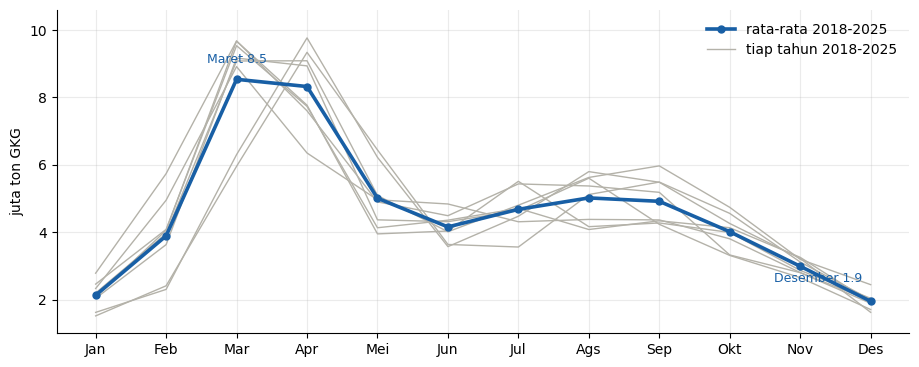

In [7]:
TAHUN_BASELINE = range(2018, 2026)

nasional = padi.groupby("tanggal").produksi_padi_ton_gkg.sum() / 1e6
baseline = nasional[nasional.index.year.isin(TAHUN_BASELINE)]
rata = baseline.groupby(baseline.index.month).mean()

fig, ax = plt.subplots(figsize=(11, 4.2))
for th in TAHUN_BASELINE:
    s = baseline[baseline.index.year == th]
    ax.plot(s.index.month, s.values, lw=1, color=WARNA["abu"], zorder=1)
ax.plot(rata.index, rata.values, lw=2.6, color=WARNA["utama"], marker="o", ms=5,
        zorder=3, label="rata-rata 2018-2025")
ax.plot([], [], lw=1, color=WARNA["abu"], label="tiap tahun 2018-2025")
ax.annotate(f"Maret {rata[3]:.1f}", (3, rata[3]), xytext=(0, 12),
            textcoords="offset points", ha="center", fontsize=9, color=WARNA["utama"])
ax.annotate(f"Desember {rata[12]:.1f}", (12, rata[12]), xytext=(-6, 14),
            textcoords="offset points", ha="right", fontsize=9, color=WARNA["utama"])
ax.set_ylim(1.0, 10.6)
ax.set_xticks(range(1, 13), NAMA_BULAN)
ax.set_ylabel("juta ton GKG")
ax.legend(frameon=False, loc="upper right")
plt.show()

## Konsentrasi produksi antar provinsi

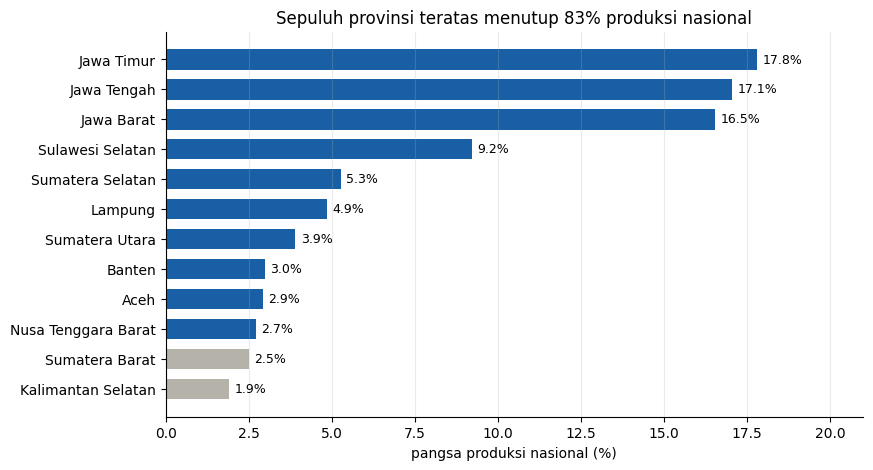

In [8]:
pangsa = (padi.groupby("provinsi").produksi_padi_ton_gkg.sum()
          / padi.produksi_padi_ton_gkg.sum() * 100).sort_values(ascending=False)
top = pangsa.head(12)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
warna = [WARNA["utama"] if n in pangsa.head(10).index else WARNA["abu"] for n in top.index]
ax.barh(top.index, top.values, color=warna, height=0.68)
for n, v in top.items():
    ax.annotate(f"{v:.1f}%", (v, n), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9)
ax.set_xlim(0, top.max() * 1.18)
ax.set_xlabel("pangsa produksi nasional (%)")
ax.set_title(f"Sepuluh provinsi teratas menutup {pangsa.head(10).sum():.0f}% produksi nasional")
ax.grid(axis="y", alpha=0)
plt.show()

In [9]:
print(f"tiga provinsi Jawa: {pangsa[['Jawa Timur', 'Jawa Tengah', 'Jawa Barat']].sum():.1f}%")
for n in (5, 10, 15):
    print(f"{n} besar: {pangsa.head(n).sum():.1f}%")

tiga provinsi Jawa: 51.4%
5 besar: 65.9%
10 besar: 83.2%
15 besar: 91.9%


### Temuan konsentrasi produksi

Produksi padi numpuk di sedikit provinsi. Tiga provinsi Jawa udah 51 persen,
sepuluh besar 83 persen.

Batang abu-abu di bawah menunjukkan sisanya sudah landai. Kalau nanti model
kesulitan di provinsi kecil, membatasi cakupan aplikasi ke sepuluh besar masih
bisa dipertanggungjawabkan.

## Pengaruh iklim

Produksi musiman, curah hujan juga musiman. Kalau dikorelasikan mentah-mentah,
angkanya tinggi tapi cuma memantulkan kalender. Jadi musimnya dihilangkan dulu di
kedua sisi: tiap nilai diubah jadi simpangan terhadap rata-rata bulan kalender yang
sama di provinsi yang sama, dibagi simpangan bakunya.

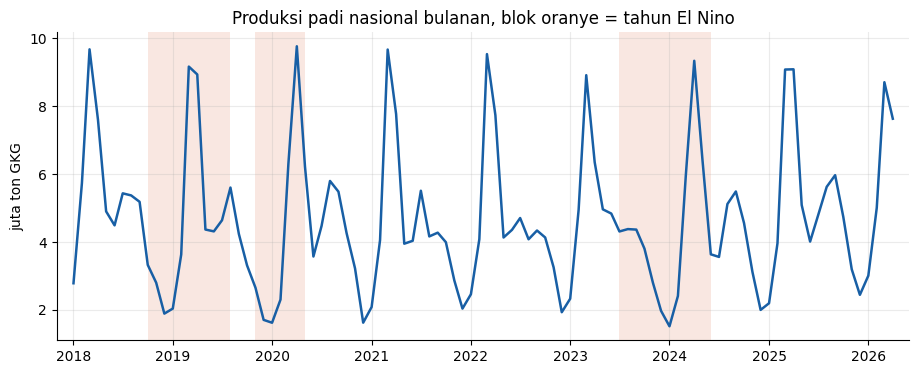

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(nasional.index, nasional.values, lw=1.8, color=WARNA["utama"], zorder=3)
for t in gab[gab.fase_enso == "El Nino"].tanggal.unique():
    ax.axvspan(t, t + pd.DateOffset(months=1), color=WARNA["oranye"],
               alpha=0.14, lw=0, zorder=1)
ax.set_xlim(nasional.index.min() - pd.DateOffset(months=2),
            nasional.index.max() + pd.DateOffset(months=2))
ax.set_ylabel("juta ton GKG")
ax.set_title("Produksi padi nasional bulanan, blok oranye = tahun El Nino")
plt.show()

In [11]:
n_bulan = gab[gab.produksi_padi_ton_gkg.notna()].groupby("provinsi").size()
d = gab[gab.provinsi.isin(n_bulan[n_bulan >= 96].index)].sort_values(["provinsi", "tanggal"]).copy()
d.loc[d.status_produksi == "potensi", "produksi_padi_ton_gkg"] = np.nan

def anomali(nilai, kunci):
    g = nilai.groupby(kunci)
    return (nilai - g.transform("mean")) / g.transform("std")

kunci = [d.provinsi, d.bulan]
d["a_produksi"] = anomali(d.produksi_padi_ton_gkg, kunci)
d["a_hujan"] = anomali(d.curah_hujan_mm, kunci)
d["a_suhu"] = anomali(d.suhu_rata_c, kunci)

d["prod3"] = d.groupby("provinsi").produksi_padi_ton_gkg.transform(lambda s: s.rolling(3).sum())
d["hujan3"] = d.groupby("provinsi").curah_hujan_mm.transform(lambda s: s.rolling(3).sum())
d["a_prod3"] = anomali(d.prod3, kunci)
d["a_hujan3"] = anomali(d.hujan3, kunci)

nas = (d.dropna(subset=["produksi_padi_ton_gkg"])
        .groupby("tanggal")
        .agg(prod=("produksi_padi_ton_gkg", "sum"),
             oni=("oni", "first"),
             fase=("fase_enso", "first")))
bl = pd.Series(nas.index.month, index=nas.index)
nas["a_prod"] = anomali(nas["prod"], bl)

print("provinsi dipakai:", d.provinsi.nunique(), "| bulan nasional:", len(nas))

provinsi dipakai: 34 | bulan nasional: 100


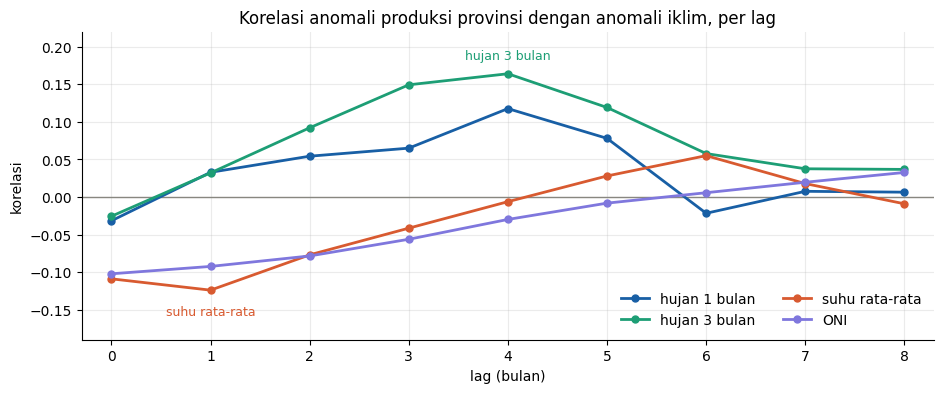

In [12]:
LAGS = list(range(9))

def korelasi_lag(target, prediktor):
    return [d[target].corr(d.groupby("provinsi")[prediktor].shift(L)) for L in LAGS]

seri = {
    "hujan 1 bulan": korelasi_lag("a_produksi", "a_hujan"),
    "hujan 3 bulan": korelasi_lag("a_prod3", "a_hujan3"),
    "suhu rata-rata": korelasi_lag("a_produksi", "a_suhu"),
    "ONI": korelasi_lag("a_produksi", "oni"),
}
warna_seri = {"hujan 1 bulan": WARNA["utama"], "hujan 3 bulan": WARNA["hijau"],
              "suhu rata-rata": WARNA["oranye"], "ONI": WARNA["ungu"]}

fig, ax = plt.subplots(figsize=(11, 4))
ax.axhline(0, color="#888780", lw=1)
for nama, y in seri.items():
    ax.plot(LAGS, y, lw=2, marker="o", ms=5, color=warna_seri[nama], label=nama)
for nama, x in (("hujan 3 bulan", 4), ("suhu rata-rata", 1)):
    y = seri[nama][x]
    ax.annotate(nama, (x, y), xytext=(0, 10 if y > 0 else -18), textcoords="offset points",
                ha="center", fontsize=9, color=warna_seri[nama])
ax.set_xlim(-0.3, 8.3)
ax.set_ylim(-0.19, 0.22)
ax.set_xlabel("lag (bulan)")
ax.set_ylabel("korelasi")
ax.set_title("Korelasi anomali produksi provinsi dengan anomali iklim, per lag")
ax.legend(loc="lower right", frameon=False, ncol=2)
plt.show()

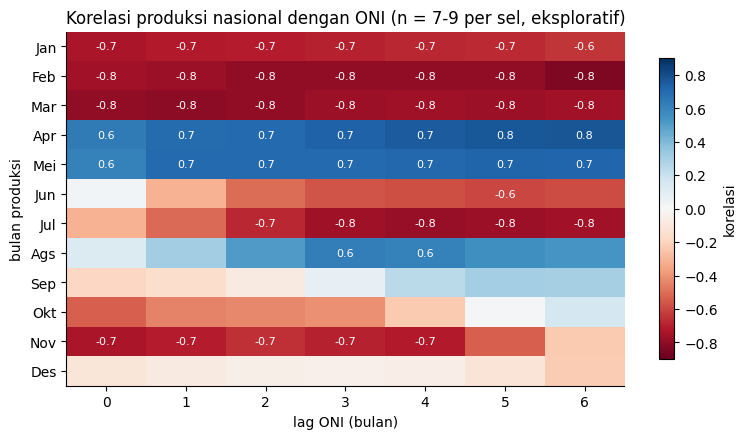

In [13]:
LAG_MAKS = 6
M = pd.DataFrame({L: {m: nas.loc[bl == m, "a_prod"].corr(nas.oni.shift(L)[bl == m])
                      for m in range(1, 13)}
                  for L in range(LAG_MAKS + 1)})

fig, ax = plt.subplots(figsize=(9, 4.6))
im = ax.imshow(M.values, cmap="RdBu", vmin=-0.9, vmax=0.9, aspect="auto")
ax.set_xticks(range(LAG_MAKS + 1))
ax.set_yticks(range(12), NAMA_BULAN)
ax.set_xlabel("lag ONI (bulan)")
ax.set_ylabel("bulan produksi")
ax.set_title("Korelasi produksi nasional dengan ONI (n = 7-9 per sel, eksploratif)")
ax.grid(False)
for i in range(12):
    for j in range(LAG_MAKS + 1):
        if abs(M.values[i, j]) >= 0.6:
            ax.text(j, i, f"{M.values[i, j]:.1f}", ha="center", va="center",
                    fontsize=8, color="white")
fig.colorbar(im, ax=ax, shrink=0.85, label="korelasi")
plt.show()

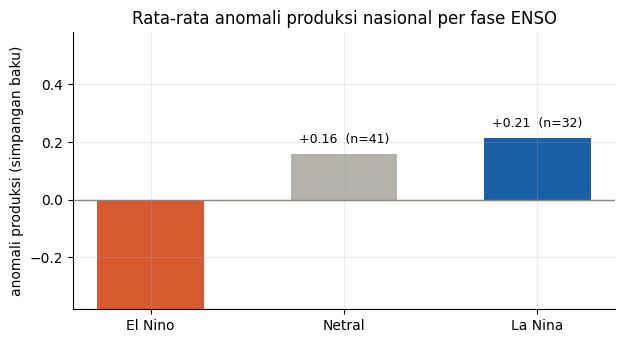

In [14]:
g = nas.groupby("fase").a_prod.agg(["mean", "count"]).reindex(["El Nino", "Netral", "La Nina"])

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.axhline(0, color="#888780", lw=1)
ax.bar(g.index, g["mean"], color=[WARNA["oranye"], WARNA["abu"], WARNA["utama"]], width=0.55)
for x, (m, c) in enumerate(zip(g["mean"], g["count"])):
    ax.annotate(f"{m:+.2f}  (n={c})", (x, m), xytext=(0, 8 if m > 0 else -16),
                textcoords="offset points", ha="center", fontsize=9)
ax.set_ylim(-0.38, 0.58)
ax.set_ylabel("anomali produksi (simpangan baku)")
ax.set_title("Rata-rata anomali produksi nasional per fase ENSO")
plt.show()

In [15]:
h3 = {L: d.a_prod3.corr(d.groupby("provinsi").a_hujan3.shift(L)) for L in range(9)}
terkuat = max(h3, key=lambda L: abs(h3[L]))
print(f"provinsi-bulan, hujan 3 bulanan terkuat: lag {terkuat}, r = {h3[terkuat]:.2f}")

oni_lag = {L: nas.a_prod.corr(nas.oni.shift(L)) for L in range(9)}
terkuat_oni = max(oni_lag, key=lambda L: abs(oni_lag[L]))
print(f"nasional, ONI terkuat: lag {terkuat_oni}, r = {oni_lag[terkuat_oni]:.2f}")

jan_mar = [nas.loc[bl == m, "a_prod"].corr(nas.oni[bl == m]) for m in (1, 2, 3)]
print("nasional lag 0, bulan Jan-Mar: r =", ", ".join(f"{v:.2f}" for v in jan_mar))

print()
print(nas.groupby("fase").a_prod.agg(["mean", "count"]).round(2))

provinsi-bulan, hujan 3 bulanan terkuat: lag 4, r = 0.16
nasional, ONI terkuat: lag 0, r = -0.31
nasional lag 0, bulan Jan-Mar: r = -0.74, -0.75, -0.80

         mean  count
fase                
El Nino -0.49     27
La Nina  0.21     32
Netral   0.16     41


# Preprocessing

## Filtering dan Penandaan Mutu

In [16]:
MIN_RIWAYAT = 96         
MIN_RATA_PRODUKSI = 1000  

# 1. Buang provinsi yang tidak layak dimodelkan
ringkas = (gab[gab.produksi_padi_ton_gkg.notna()]
           .groupby("provinsi").produksi_padi_ton_gkg.agg(n="size", rata="mean"))

riwayat_pendek = ringkas.index[ringkas.n < MIN_RIWAYAT]
bukan_sentra = ringkas.index[ringkas.rata < MIN_RATA_PRODUKSI]
dibuang = sorted(set(riwayat_pendek) | set(bukan_sentra))

model = gab[~gab.provinsi.isin(dibuang)].sort_values(["provinsi", "tanggal"]).copy()

# 2. Kosongkan curah hujan pada bulan yang datanya belum lengkap.
belum_lengkap = model.hari_data.notna() & (model.hari_data < 28)
model.loc[belum_lengkap, "curah_hujan_mm"] = np.nan

# 3. Pisahkan realisasi dari angka potensi BPS.
model["produksi_realisasi"] = model.produksi_padi_ton_gkg.where(model.status_produksi != "potensi")
model["produksi_potensi_bps"] = model.produksi_padi_ton_gkg.where(model.status_produksi == "potensi")

model = model.reset_index(drop=True)

print("riwayat terlalu pendek :", ", ".join(sorted(riwayat_pendek)))
print("bukan daerah produksi  :", ", ".join(sorted(bukan_sentra)))
print(f"dibuang {len(dibuang)} provinsi, pangsa produksi terbuang "
      f"{gab[gab.provinsi.isin(dibuang)].produksi_padi_ton_gkg.sum() / gab.produksi_padi_ton_gkg.sum() * 100:.3f}%")
print(f"baris: {len(gab)} -> {len(model)} | provinsi: {model.provinsi.nunique()}")
print(f"realisasi: {model.produksi_realisasi.notna().sum()} baris | "
      f"potensi BPS: {model.produksi_potensi_bps.notna().sum()} baris")

riwayat terlalu pendek : Papua Barat Daya, Papua Pegunungan, Papua Selatan, Papua Tengah
bukan daerah produksi  : DKI Jakarta, Kepulauan Riau, Papua Barat Daya, Papua Pegunungan, Papua Tengah
dibuang 6 provinsi, pangsa produksi terbuang 0.215%
baris: 4940 -> 4160 | provinsi: 32
realisasi: 3200 baris | potensi BPS: 192 baris


## Handling Missing Value

In [17]:
# Cek Missing Value
print("Missing Values:\n", model.isnull().sum())

Missing Values:
 tanggal                      0
tahun                        0
bulan                        0
provinsi                     0
wilayah_34                 768
sumber                     768
status_luas_panen          768
status_produksi            768
luas_panen_ha              768
produksi_padi_ton_gkg      768
produksi_beras_ton         768
standing_crop_ha          1088
vegetatif_awal_ha         1088
vegetatif_akhir_ha        1088
generatif_ha              1088
persiapan_lahan_ha        1088
potensi_gagal_panen_ha    1088
lahan_bera_ha             1088
tanaman_selain_padi_ha    1088
curah_hujan_mm              64
suhu_rata_c                 32
suhu_maks_c                 32
suhu_min_c                  32
n_kab_kota                  32
hari_data                   32
oni                         64
dmi                        160
fase_enso                   64
fase_iod                   160
produksi_realisasi         960
produksi_potensi_bps      3968
dtype: int64


## Handling Duplicate Data

In [18]:
print("Jumlah duplikat identik:", model.duplicated().sum())

model = model.drop_duplicates(keep="first")

print("Jumlah data setelah hapus duplikat identik:", len(model))


Jumlah duplikat identik: 0
Jumlah data setelah hapus duplikat identik: 4160


# Feature Engineering

In [19]:
LAG_PRODUKSI = 6   # realisasi BPS terlambat ~6 bulan

# Semua penggeseran WAJIB per provinsi. Tanpa groupby, nilai provinsi terakhir akan bocor jadi lag provinsi berikutnya.
def lag(kolom, k):
    return model.groupby("provinsi")[kolom].shift(k)

# Baris contoh untuk menampilkan hasil tiap fitur
CONTOH = (model.provinsi == "Jawa Barat") & (model.tahun == 2020)
KOLOM_CONTOH = ["tanggal", "produksi_realisasi"]

## Curah Hujan Tiga Bulanan

In [20]:
model["hujan3"] = model.groupby("provinsi").curah_hujan_mm.transform(lambda s: s.rolling(3).sum())

model.loc[CONTOH, ["tanggal", "curah_hujan_mm", "hujan3"]].head(4)

,tanggal,curah_hujan_mm,hujan3
958,2020-01-01,375.89,951.42
959,2020-02-01,582.43,1358.26
960,2020-03-01,593.23,1551.55
961,2020-04-01,313.95,1489.61


## Lag Produksi

In [21]:
model["produksi_lag6"] = lag("produksi_realisasi", LAG_PRODUKSI)
model["produksi_lag12"] = lag("produksi_realisasi", 12)

model.loc[CONTOH, KOLOM_CONTOH + ["produksi_lag6", "produksi_lag12"]].head(4)

,tanggal,produksi_realisasi,produksi_lag6,produksi_lag12
958,2020-01-01,261729.10,850948.77,247674.94
959,2020-02-01,163278.53,871335.04,324349.34
960,2020-03-01,423836.77,752680.61,1399151.01
961,2020-04-01,1696126.86,559023.12,1656631.53


## Penanda Skala Provinsi

In [22]:
model["produksi_rata6_lag6"] = (model.groupby("provinsi").produksi_realisasi
                                .transform(lambda s: s.rolling(6).mean())
                                .groupby(model.provinsi).shift(LAG_PRODUKSI))
model["rasio_lag12_rata6"] = model.produksi_lag12 / model.produksi_rata6_lag6

model.loc[CONTOH, KOLOM_CONTOH + ["produksi_rata6_lag6", "rasio_lag12_rata6"]].head(4)

,tanggal,produksi_realisasi,produksi_rata6_lag6,rasio_lag12_rata6
958,2020-01-01,261729.10,9.440436e+05,0.262355
959,2020-02-01,163278.53,1.035208e+06,0.313318
960,2020-03-01,423836.77,9.274628e+05,1.508579
961,2020-04-01,1696126.86,7.445281e+05,2.225076


## Lag Cuaca

In [23]:
model["hujan3_lag3"] = lag("hujan3", 3)
model["hujan3_lag4"] = lag("hujan3", 4)
model["hujan_lag1"] = lag("curah_hujan_mm", 1)
model["suhu_lag1"] = lag("suhu_rata_c", 1)
model["suhu_lag2"] = lag("suhu_rata_c", 2)

model.loc[CONTOH, ["tanggal", "hujan3_lag3", "hujan3_lag4", "suhu_lag1", "suhu_lag2"]].head(4)

,tanggal,hujan3_lag3,hujan3_lag4,suhu_lag1,suhu_lag2
958,2020-01-01,74.51,42.13,25.77,25.68
959,2020-02-01,236.89,74.51,25.29,25.77
960,2020-03-01,629.00,236.89,25.00,25.29
961,2020-04-01,951.42,629.00,25.14,25.00


## Lag ONI

In [24]:
model["oni_lag1"] = lag("oni", 1)
model["oni_lag2"] = lag("oni", 2)

model.loc[CONTOH, ["tanggal", "oni", "oni_lag1", "oni_lag2"]].head(4)

,tanggal,oni,oni_lag1,oni_lag2
958,2020-01-01,0.75,0.72,0.51
959,2020-02-01,0.71,0.75,0.72
960,2020-03-01,0.66,0.71,0.75
961,2020-04-01,0.57,0.66,0.71


## Interaksi ONI dengan Panen Raya

In [25]:
model["panen_raya"] = model.bulan.isin([1, 2, 3]).astype(int)
model["oni_lag2_panen_raya"] = model.oni_lag2 * model.panen_raya

model.loc[CONTOH, ["tanggal", "bulan", "panen_raya", "oni_lag2", "oni_lag2_panen_raya"]].head(4)

,tanggal,bulan,panen_raya,oni_lag2,oni_lag2_panen_raya
958,2020-01-01,1,1,0.51,0.51
959,2020-02-01,2,1,0.72,0.72
960,2020-03-01,3,1,0.75,0.75
961,2020-04-01,4,0,0.71,0.00


## Daftar Fitur dan Pemeriksaan

In [26]:
FITUR = ["produksi_lag6", "produksi_lag12", "produksi_rata6_lag6", "rasio_lag12_rata6",
         "hujan3_lag3", "hujan3_lag4", "hujan_lag1", "suhu_lag1", "suhu_lag2",
         "oni_lag1", "oni_lag2", "oni_lag2_panen_raya", "panen_raya"]

siap = model.dropna(subset=FITUR + ["produksi_realisasi"])
print(f"{len(FITUR)} fitur | baris siap latih: {len(siap)} dari "
      f"{model.produksi_realisasi.notna().sum()} baris bertarget")
print(f"rentang: {siap.tanggal.min():%Y-%m} s.d. {siap.tanggal.max():%Y-%m} | "
      f"{siap.provinsi.nunique()} provinsi")

13 fitur | baris siap latih: 2816 dari 3200 baris bertarget
rentang: 2019-01 s.d. 2026-04 | 32 provinsi


## Encoding

In [27]:
# Urut alfabetis supaya kodenya stabil dan bisa diulang.
PROVINSI = sorted(model.provinsi.unique())
KODE_PROVINSI = {nama: i for i, nama in enumerate(PROVINSI)}

model["provinsi_kode"] = model.provinsi.map(KODE_PROVINSI)
model["bulan_kode"] = model.bulan - 1        

assert model.groupby("provinsi").provinsi_kode.nunique().eq(1).all()
assert model.provinsi_kode.notna().all()

print(f"{len(PROVINSI)} provinsi -> kode 0..{len(PROVINSI) - 1}")
print(f"bulan -> kode 0..11")
model[["provinsi", "provinsi_kode", "bulan", "bulan_kode"]].head(3)

32 provinsi -> kode 0..31
bulan -> kode 0..11


,provinsi,provinsi_kode,bulan,bulan_kode
0,Aceh,0,1,0
1,Aceh,0,2,1
2,Aceh,0,3,2


In [28]:
(ROOT / "data/processed/kode_provinsi.json").write_text(
    json.dumps(KODE_PROVINSI, indent=2, ensure_ascii=False), encoding="utf-8")

print("tersimpan:", ROOT / "data/processed/kode_provinsi.json")

tersimpan: e:\Platinum\Important\Collage\Semester 7\PDA\data\processed\kode_provinsi.json


In [29]:
FITUR = ["produksi_lag6", "produksi_lag12", "produksi_rata6_lag6", "rasio_lag12_rata6",
         "hujan3_lag3", "hujan3_lag4", "hujan_lag1", "suhu_lag1", "suhu_lag2",
         "oni_lag1", "oni_lag2", "oni_lag2_panen_raya", "panen_raya",
         "bulan_kode", "provinsi_kode"]

FITUR_KATEGORIK = ["bulan_kode", "provinsi_kode"]

# Feature Selection

In [30]:
KUNCI = ["tanggal", "tahun", "bulan", "provinsi"]
TARGET = "produksi_realisasi"

tabel = model[KUNCI + [TARGET] + FITUR].dropna().reset_index(drop=True)

print(f"bentuk: {tabel.shape} | missing: {int(tabel.isna().sum().sum())}")
print(f"{tabel.tanggal.min():%Y-%m} s.d. {tabel.tanggal.max():%Y-%m} | "
      f"{tabel.provinsi.nunique()} provinsi")
print(f"baris per provinsi: {tabel.groupby('provinsi').size().unique()}")

bentuk: (2816, 20) | missing: 0
2019-01 s.d. 2026-04 | 32 provinsi
baris per provinsi: [88]


In [31]:
# tabel.to_csv(ROOT / "data/processed/dataset_model.csv", index=False)
# print("tersimpan:", ROOT / "data/processed/dataset_model.csv")

In [32]:
df = pd.read_csv(ROOT / "data/processed/dataset_model.csv", parse_dates=["tanggal"])
df.head(20)

,tanggal,tahun,bulan,provinsi,produksi_realisasi,produksi_lag6,produksi_lag12,produksi_rata6_lag6,rasio_lag12_rata6,hujan3_lag3,hujan3_lag4,hujan_lag1,suhu_lag1,suhu_lag2,oni_lag1,oni_lag2,oni_lag2_panen_raya,panen_raya,bulan_kode,provinsi_kode
0,2019-01-01,2019,1,Aceh,42459.41,93821.52,76118.47,180594.570000,0.421488,757.92,606.35,207.75,23.96,23.83,1.04,0.82,0.82,1,0,0
1,2019-02-01,2019,2,Aceh,176086.76,142895.96,142876.76,180597.770000,0.791132,970.01,757.92,120.83,24.07,23.96,1.05,1.04,1.04,1,1,0
2,2019-03-01,2019,3,Aceh,385742.63,192853.32,375841.91,150099.671667,2.503949,976.23,970.01,105.07,24.67,24.07,0.99,1.05,1.05,1,2,0
3,2019-04-01,2019,4,Aceh,194414.30,153129.92,336742.80,119497.525000,2.817990,707.96,976.23,124.04,24.91,24.67,0.94,0.99,0.00,0,3,0
4,2019-05-01,2019,5,Aceh,101546.59,126142.58,96372.36,124459.228333,0.774329,433.65,707.96,137.81,25.36,24.91,0.87,0.94,0.00,0,4,0
5,2019-06-01,2019,6,Aceh,90110.62,86859.43,37912.07,132617.121667,0.285876,349.94,433.65,152.12,25.14,25.36,0.82,0.87,0.00,0,5,0
6,2019-07-01,2019,7,Aceh,112226.11,42459.41,93821.52,124056.770000,0.756279,366.92,349.94,134.12,24.70,25.14,0.71,0.82,0.00,0,6,0
7,2019-08-01,2019,8,Aceh,107035.34,176086.76,142895.96,129588.570000,1.102690,413.97,366.92,119.03,24.64,24.70,0.59,0.71,0.00,0,7,0
8,2019-09-01,2019,9,Aceh,149259.37,385742.63,192853.32,161736.788333,1.192390,424.05,413.97,140.67,24.29,24.64,0.38,0.59,0.00,0,8,0
9,2019-10-01,2019,10,Aceh,182189.72,194414.30,153129.92,168617.518333,0.908150,405.27,424.05,164.98,24.44,24.29,0.20,0.38,0.00,0,9,0


# Split Train & Test